In [1]:
# 安裝套件
%pip install --upgrade pip
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


🔴 錄製中：11.6% [1390/12000]


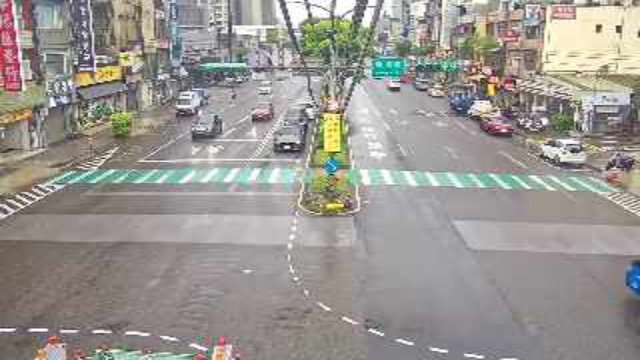


🛑 手動中斷錄製
✅ 錄製結束，存儲於: c:\Users\johnyou\Desktop\CCTV_carCounter\origin.mp4


In [ ]:
# 錄製影片素材
import cv2
import os
import time
from datetime import datetime
from dotenv import load_dotenv
from IPython.display import clear_output, display, Image

load_dotenv()

os.environ["OPENCV_FFMPEG_CAPTURE_OPTIONS"] = "timeout;10000000|rw_timeout;10000000"

# 參數設定
CCTV_URL = os.environ["CCTV_URL"]
RECORD_SECONDS = 1200
FPS = 20.0

# 建立儲存路徑
save_path = "origin.mp4"

# 開啟串流
cap = cv2.VideoCapture(CCTV_URL)

if not cap.isOpened():
    print(f"❌ 無法開啟串流 {CCTV_URL}")
else:
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))  or 1280
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) or 720
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(save_path, fourcc, FPS, (width, height))

    print(f"🚀 開始錄製純影片...")
    print(f"📂 儲存路徑: {save_path}")
    print(f"⏱️  預計時長: {RECORD_SECONDS} 秒")

    TOTAL_FRAMES = int(RECORD_SECONDS * FPS)
    frame_count = 0

    try:
        while frame_count < TOTAL_FRAMES:
            ret, frame = cap.read()
            if not ret:
                print("⚠️ 串流暫時中斷，重試中...")
                time.sleep(1)
                continue

            out.write(frame)
            frame_count += 1

            if frame_count % int(FPS) == 0:
                clear_output(wait=True)
                pct = (frame_count / TOTAL_FRAMES) * 100
                print(f"🔴 錄製中：{pct:.1f}% [{frame_count}/{TOTAL_FRAMES}]")
                resize_frame = cv2.resize(frame, (640, 360))
                _, encoded_img = cv2.imencode('.jpg', resize_frame)
                display(Image(data=encoded_img.tobytes()))

    except KeyboardInterrupt:
        print("\n🛑 手動中斷錄製")

    finally:
        cap.release()
        out.release()
        print(f"✅ 錄製結束，存儲於: {os.path.abspath(save_path)}")

In [ ]:
# 上傳影片並取得標註、計數
import cv2
import os
import base64
import json
import numpy as np
from collections import defaultdict
from dotenv import load_dotenv
from inference_sdk import InferenceHTTPClient
from inference_sdk.webrtc import VideoFileSource, StreamConfig, VideoMetadata

load_dotenv()

# --- 1. 影片切片配置 (每 10 分鐘一段) ---
INPUT_VIDEO = "origin.mp4"
CHUNK_DURATION_MIN = 10
CHUNK_DURATION_SEC = CHUNK_DURATION_MIN * 60

def split_video(video_path, chunk_sec):
    """將大影片切片成多個 10 分鐘的小影片，返回小影片路徑清單"""
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frames_per_chunk = int(fps * chunk_sec)
    
    chunk_files = []
    chunk_index = 0
    frame_count = 0
    out = None
    
    print("正在進行影片本地切片...")
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        if frame_count % frames_per_chunk == 0:
            if out:
                out.release()
            chunk_file = f"temp_chunk_{chunk_index}.mp4"
            out = cv2.VideoWriter(chunk_file, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
            chunk_files.append(chunk_file)
            chunk_index += 1
            
        out.write(frame)
        frame_count += 1
        
    if out:
        out.release()
    cap.release()
    print(f"切片完成，共切成 {len(chunk_files)} 段。")
    return chunk_files, fps

# 執行切片
chunk_files, original_fps = split_video(INPUT_VIDEO, CHUNK_DURATION_SEC)

# --- 2. 全局狀態初始化 ---
all_frames_data = []         # 儲存所有影格資訊：(全局時間戳, 全局影格ID, 影像數據, 該影格結算數量)
class_ids = defaultdict(set) # 全局計數器：追蹤不重複的 tracker_id
global_frame_offset = 0     # 用於累加不同片段的影格 ID
global_time_offset_ms = 0.0 # 用於累加不同片段的時間戳

VIDEO_OUTPUT = "annotated_image"
DATA_OUTPUTS = ["predictions", "annotated_image"]

# --- 3. 初始化 Roboflow 雲端客戶端 ---
client = InferenceHTTPClient.init(
    api_url="https://serverless.roboflow.com",
    api_key=os.environ["ROBOFLOW_API_KEY"],
)

# --- 4. 逐段提交並處理 ---
for chunk_path in chunk_files:
    print(f"\n[開始處理片段] -> {chunk_path}")
    
    # 針對當前片段建立 WebRTC 串流
    source = VideoFileSource(chunk_path, realtime_processing=False)
    config = StreamConfig(
        stream_output=[],
        data_output=DATA_OUTPUTS,
        requested_plan="webrtc-gpu-medium",
        requested_region="us",
    )
    
    session = client.webrtc.stream(
        source=source,
        workflow="carcounter",
        workspace=os.environ["ROBOFLOW_WORKSPACE"],
        image_input="image",
        config=config,
    )
    
    max_chunk_frame_id = 0
    max_chunk_pts_ms = 0.0

    @session.on_data()
    def on_data(data: dict, metadata: VideoMetadata):
        global class_ids, all_frames_data, max_chunk_frame_id, max_chunk_pts_ms
        
        # 解析預測物件
        raw_predictions = data.get("predictions", [])
        predictions_list = []
        if isinstance(raw_predictions, dict):
            predictions_list = raw_predictions.get("predictions", [])
        elif isinstance(raw_predictions, str):
            try:
                parsed = json.loads(raw_predictions)
                predictions_list = parsed.get("predictions", []) if isinstance(parsed, dict) else parsed
            except json.JSONDecodeError:
                pass
        elif isinstance(raw_predictions, list):
            predictions_list = raw_predictions

        # 更新計數邏輯
        for pred in predictions_list:
            if not isinstance(pred, dict):
                continue
            track_id = pred.get("tracker_id")
            y_center = pred.get("y", 0)
            vtype = pred.get("class")
            
            if track_id is None or vtype is None or y_center <= 60:
                continue
            # 若此物件在前面的片段或其他類別已被計數過，則跳過
            if any(track_id in ids for ids in class_ids.values()):
                continue
                
            class_ids[vtype].add(track_id)
            current_total = sum(len(ids) for ids in class_ids.values())
            print(f"【偵測成功】全局ID: {track_id} | 類型: {vtype} | 目前全局總量: {current_total}")

        # 解析並儲存影像（先不繪製文字，只解碼暫存）
        if VIDEO_OUTPUT in data:
            img_data = base64.b64decode(data[VIDEO_OUTPUT]["value"])
            img = cv2.imdecode(np.frombuffer(img_data, np.uint8), cv2.IMREAD_COLOR)
            
            # 計算全局影格 ID 與時間戳
            current_global_frame = global_frame_offset + metadata.frame_id
            current_global_pts = global_time_offset_ms + (metadata.pts * metadata.time_base * 1000)
            
            if metadata.frame_id > max_chunk_frame_id:
                max_chunk_frame_id = metadata.frame_id
            if (metadata.pts * metadata.time_base * 1000) > max_chunk_pts_ms:
                max_chunk_pts_ms = metadata.pts * metadata.time_base * 1000
                
            # 複製當前累計的計數快照（用於最後繪製）
            current_counts = {cls: len(ids) for cls, ids in class_ids.items()}
            all_frames_data.append((current_global_pts, current_global_frame, img, current_counts))

    # 執行當前段落，完成後才會換下一段
    session.run()
    
    # 更新下一段影片的全局偏移量
    global_frame_offset += (max_chunk_frame_id + 1)
    global_time_offset_ms += max_chunk_pts_ms
    
    # 刪除已處理完畢的本地暫存影片片段
    try:
        os.remove(chunk_path)
    except OSError:
        pass

# --- 5. 最終一併繪製標籤並生成影片 ---
print("\n=== 所有片段提交完畢，開始繪製標籤並輸出最終影片 ===")

if all_frames_data:
    # 依全局影格 ID 排序
    all_frames_data.sort(key=lambda x: x[1])
    
    h, w = all_frames_data[0][2].shape[:2]
    out = cv2.VideoWriter("labeled.mp4", cv2.VideoWriter_fourcc(*"mp4v"), original_fps, (w, h))
    
    for timestamp, frame_id, img, counts in all_frames_data:
        total = sum(counts.values())
        
        # 繪製計數警戒線
        cv2.line(img, (0, 60), (w, 60), (255, 255, 0), 1)
        
        # 繪製總計文字
        cv2.putText(img, f"Total: {total}", (10, 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
        
        # 繪製各類別細項
        y = 38
        for cls_name, count in sorted(counts.items()):
            cv2.putText(img, f"{cls_name}: {count}",
                        (10, y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
            y += 18
            
        out.write(img)
        
    out.release()
    
    final_total = sum(len(ids) for ids in class_ids.values())
    summary = ", ".join(f"{cls}={len(ids)}" for cls, ids in sorted(class_ids.items()))
    print(f"\n=== 最終計數總結 === Total={final_total}, {summary}")
    print(f"成功將 {len(all_frames_data)} 個影格合併輸出至 -> labeled.mp4")
else:
    print("未接收到任何影像數據。")
